Name: **Stephane Chambrelain Talla Fotsing**  
Student Number: **ST139766**  
Program: **Data Analytics and Artificial Intelligence**  
Course - **Introduction to Artificial Intelligence**  
**Assignment 6: House Price Prediction Using California Housing Data**

## **Assignment Simple machine Learning Project cycle**

### **_House Price Prediction Using California Housing Data_**
This dataset provides information about house prices in California. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "California Housing Dataset" from sklearn.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (California Housing):
* MedInc: Median income in block group
* HouseAge: Median house age in block group
* AveRooms: Average number of rooms per household
* AveBedrms: Average number of bedrooms per household
* Population: Block group population
* AveOccup: Average number of household members
* Latitude: Block group latitude
* Longitude: Block group longitude
* MedHouseVal (Target): Median house value in block group




In [14]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
# --- Data Collection and Loading ---
# TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `fetch_california_housing()` from `sklearn.datasets`
# Load dataset and convert to DataFrame:
# Add your code here:
# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
# Create a DataFrame containing the features and target
df = housing.frame

In [16]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.
# Add your code here:
# Display the first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.
# Add your code here:
# Check column names, data types, and non-null counts
df.info()
print("-" * 42)
# View summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
------------------------------------------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [18]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.
# Add your code here:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


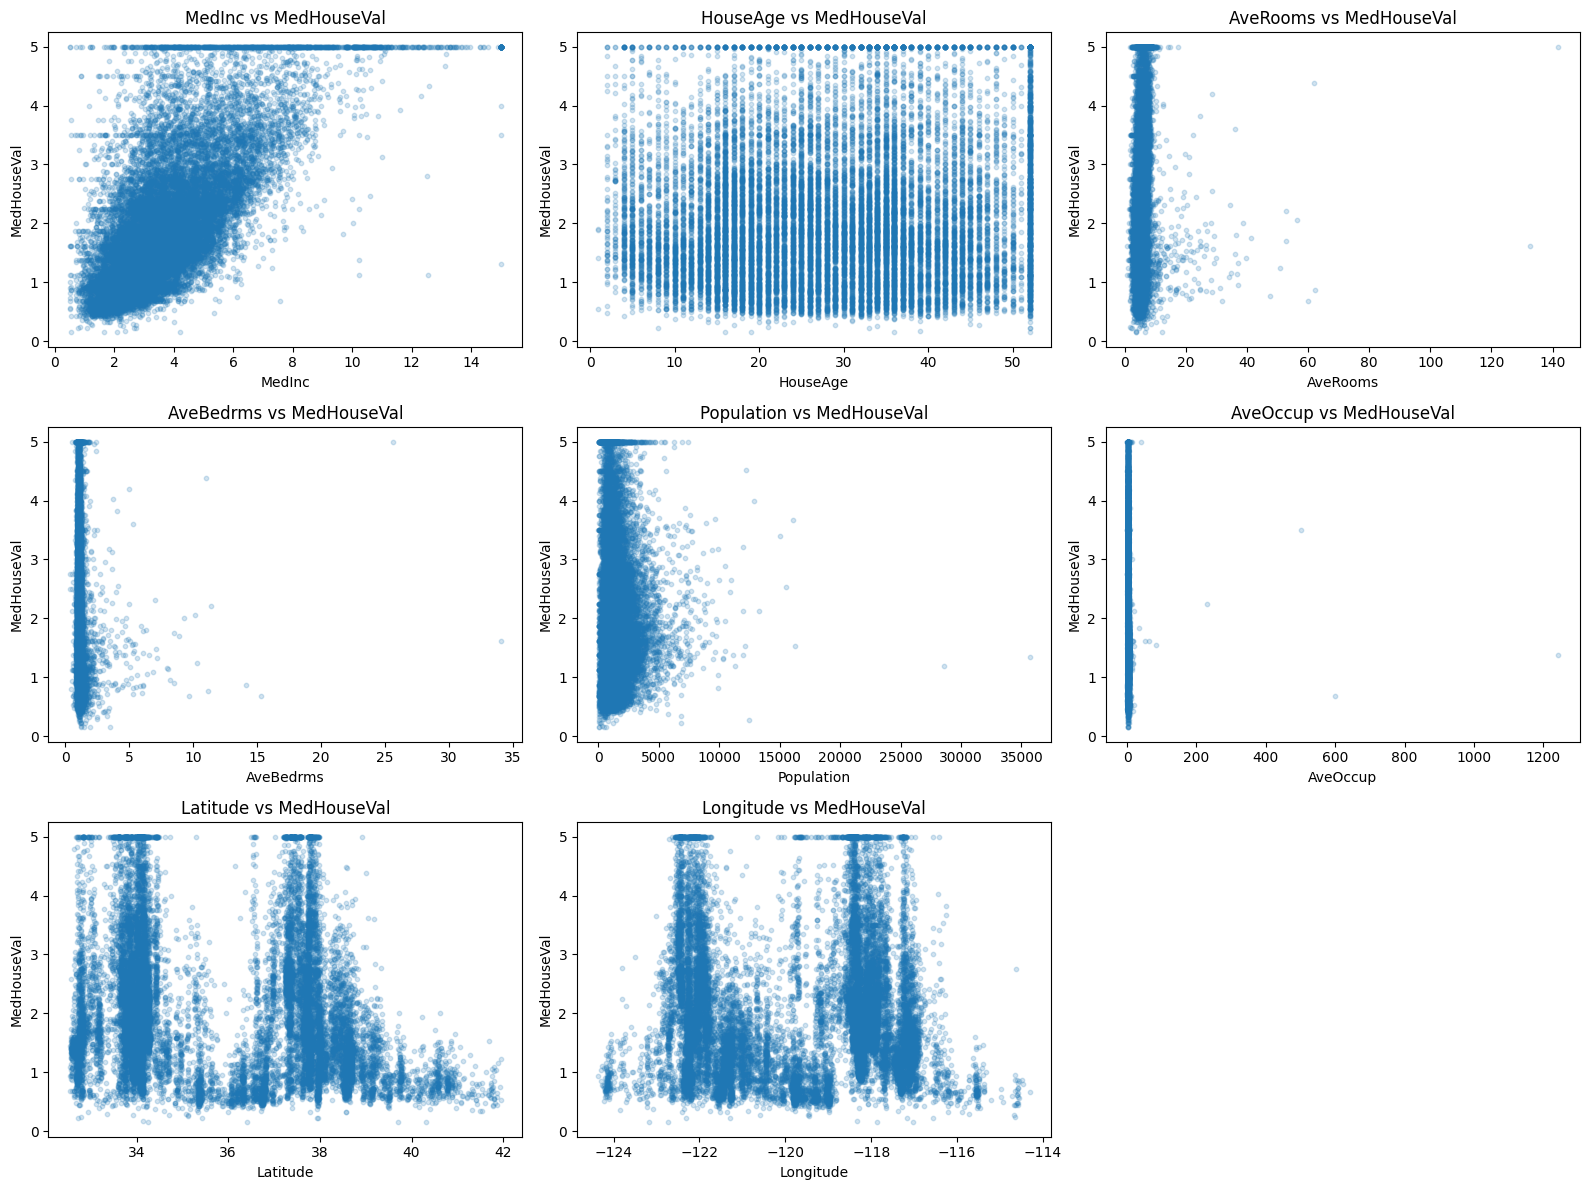

In [19]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
# Example: Use `plt.scatter()` to visualize the relationship between 'MedInc' and 'MedHouseVal'.
# Add your code here:
# Plot each feature against the target
features = df.drop(columns="MedHouseVal").columns
plt.figure(figsize=(16, 12))
for i, feature in enumerate(features, start=1):
    plt.subplot(3, 3, i)
    plt.scatter(df[feature], df["MedHouseVal"], alpha=0.2, s=10)
    plt.xlabel(feature)
    plt.ylabel("MedHouseVal")
    plt.title(f"{feature} vs MedHouseVal")
plt.tight_layout()
plt.show()

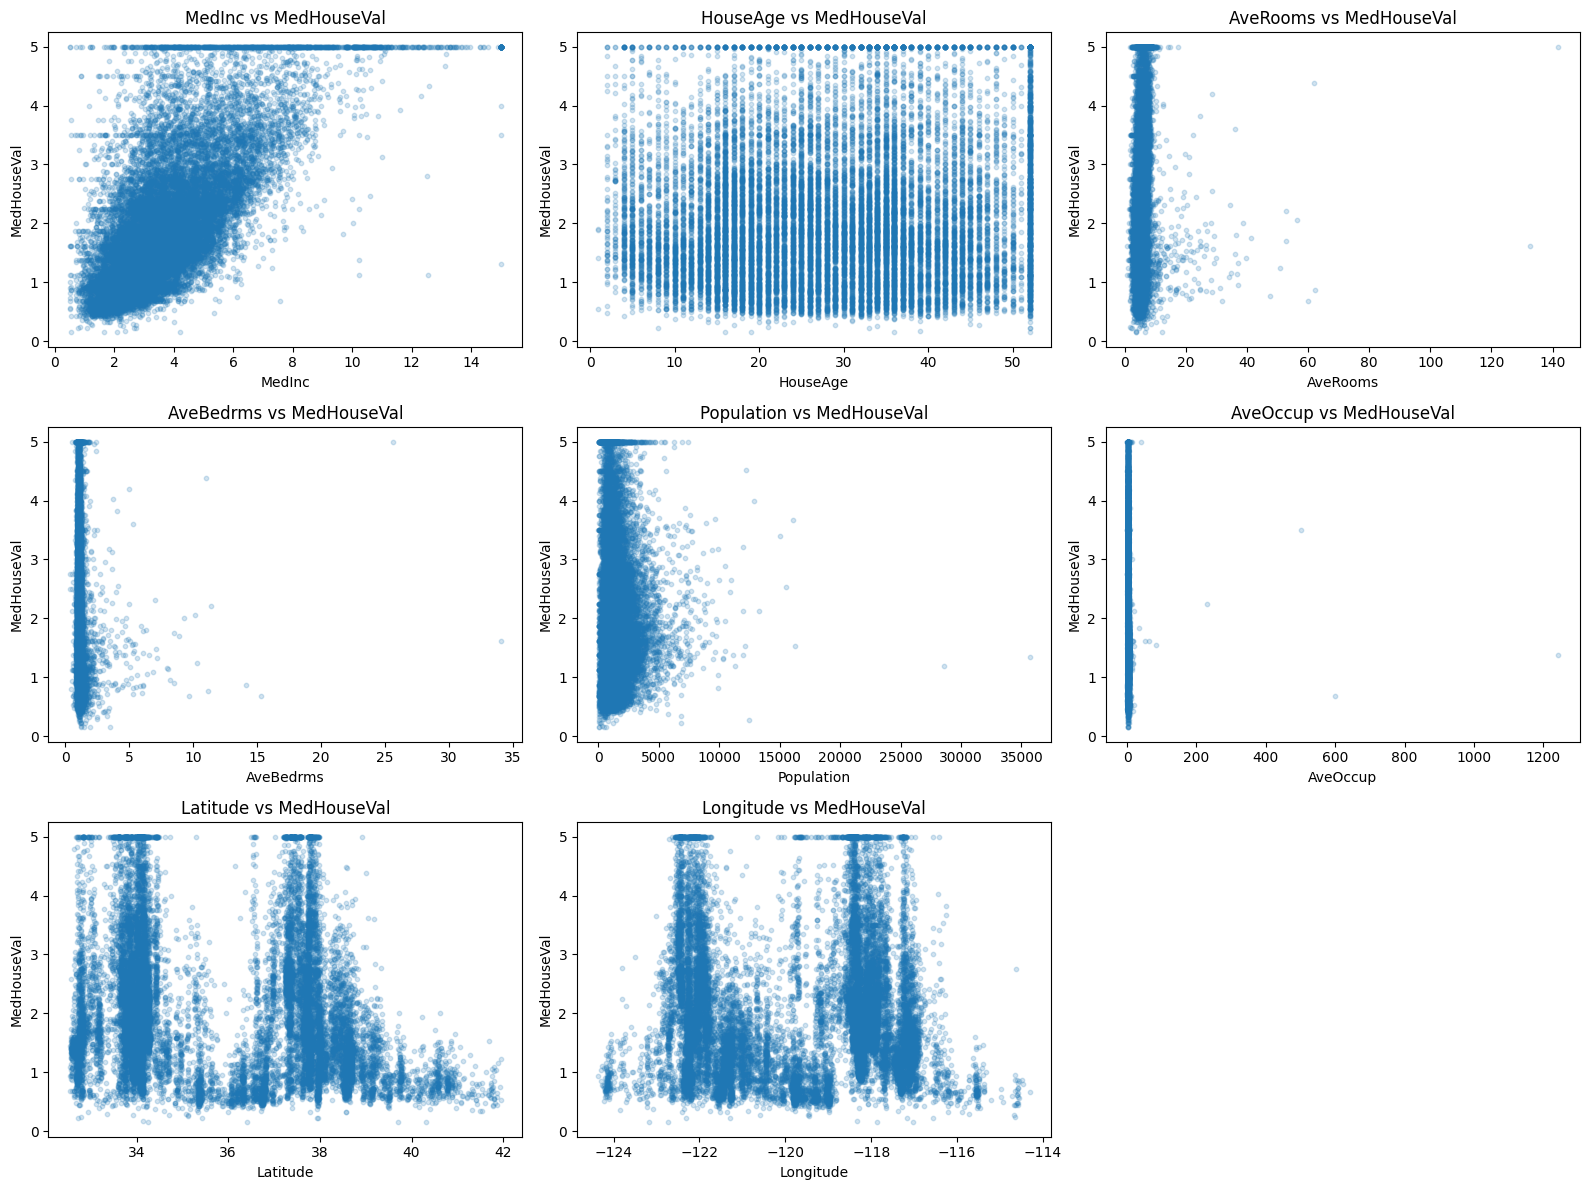

In [20]:
# TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
# Hint: The function should loop over a list of features and plot scatter plots for each.
# Define your function here:
def plot_scatter(data, features):
    plt.figure(figsize=(16, 12))
    for i, feature in enumerate(features, start=1):
        plt.subplot(3, 3, i)
        plt.scatter(data[feature], data["MedHouseVal"], alpha=0.2, s=10)
        plt.xlabel(feature)
        plt.ylabel("MedHouseVal")
        plt.title(f"{feature} vs MedHouseVal")
    plt.tight_layout()
    plt.show()
# Call the function with all eight features
features = df.drop(columns="MedHouseVal").columns.tolist()
plot_scatter(df, features)

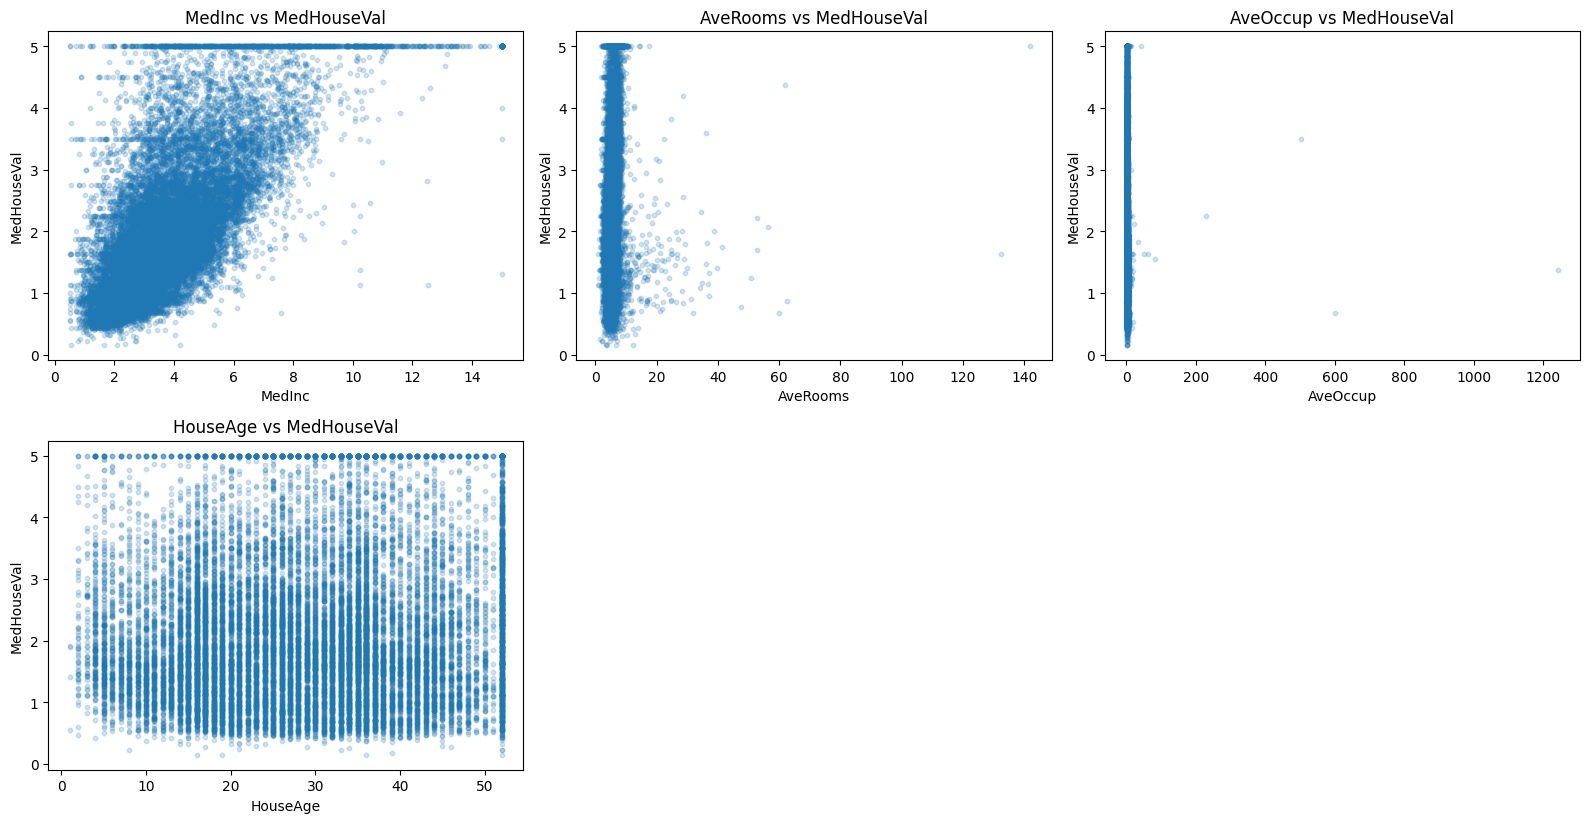

In [21]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Features: ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
# Target: 'MedHouseVal'
# Add your code here:
features = ["MedInc", "AveRooms", "AveOccup", "HouseAge"]
plot_scatter(df, features)

In [22]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.
# Define X (features) and y (target) and perform the train-test split:
# Define features and target
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]
# Split: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# TODO: Choose an appropriate regression model.
# Hint: Use `LinearRegression()` from `sklearn.linear_model`.
# Define your regression model here:
# Create the linear regression model
model = LinearRegression()

In [24]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.
# Add your code here:
# Train the model using the training data
model.fit(X_train, y_train)

LinearRegression()

In [25]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.
# Predict on the test set and calculate the evaluation metrics:
# Predict house values for the test set
y_pred = model.predict(X_test)
# Calculate RMSE and R-squared
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

RMSE: 0.7456
R-squared: 0.5758


In [26]:
# --- Model Prediction ---
# TODO: Predict Median House Value from a new set of feature inputs.
# Example new data: 'MedInc' = 3, 'HouseAge' = 30, 'AveRooms' = 6, 'AveOccup' = 3, 'Latitude' = 34, 'Longitude' = -118, 'AveBedrms' = 1, 'Population' = 1500
# Hint: Use `.predict()` on a new data array.
# Add your prediction code here:
# Create new data with the same column order as the training features
new_data = pd.DataFrame({"MedInc": [3],"HouseAge": [30], "AveRooms": [6], "AveBedrms": [1],
                         "Population": [1500], "AveOccup": [3], "Latitude": [34], "Longitude": [-118]
                        }, columns=X.columns)
# Predict the median house value
prediction = model.predict(new_data)
print(f"Predicted Median House Value: ${prediction[0] * 100000:,.2f}")

Predicted Median House Value: $154,866.33


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
!ls -la "/content/drive/MyDrive"

total 545
drwx------ 5 root root   4096 Sep 13 20:38  .
drwx------ 5 root root   4096 Sep 13 20:38  ..
-rw------- 1 root root    175 Nov 27  2021 'Altyd gefokus - Midterm Exam-Online.gdoc'
-rw------- 1 root root     48 Jan 17  2020  BackupRestoreTest.txt
drwx------ 2 root root   4096 May  3  2021  Classroom
-rw------- 1 root root    175 Oct  3  2024 'Client Intake Form - Fillable - 2024.gdoc'
-rw------- 1 root root 531006 Sep 30  2024 'Client Intake Form - Fillable - 2024.pdf'
drwx------ 2 root root   4096 May  1 12:32 'Colab Notebooks'
-rw------- 1 root root   3815 May 26 15:49  employees.csv
drwx------ 2 root root   4096 Feb 26  2021  Takeout


In [29]:
!find "/content/drive/MyDrive/Colab Notebooks" -iname "*Lesson*6*ml*basic*.ipynb"

/content/drive/MyDrive/Colab Notebooks/Lesson_6_ml_basic_assignment.ipynb


In [30]:
!git clone https://github.com/StephaneTF/colab-git-assignment2-ST.git /content/colab-git-assignment2-ST

Cloning into '/content/colab-git-assignment2-ST'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 60 (delta 23), reused 23 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 1.15 MiB | 6.26 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [31]:
!ls -la /content/colab-git-assignment2-ST

total 1036
drwxr-xr-x 6 root root   4096 Sep 13 20:41  .
drwxr-xr-x 1 root root   4096 Sep 13 20:41  ..
-rw-r--r-- 1 root root   5415 Sep 13 20:41  assignment2.ipynb
drwxr-xr-x 2 root root   4096 Sep 13 20:41  Assignment_8
drwxr-xr-x 2 root root   4096 Sep 13 20:41  Assignment_9
drwxr-xr-x 8 root root   4096 Sep 13 20:41  .git
drwxr-xr-x 2 root root   4096 Sep 13 20:41  Lesson_10_assignment
-rw-r--r-- 1 root root  12704 Sep 13 20:41  Lesson_3_assignment.ipynb
-rw-r--r-- 1 root root  80271 Sep 13 20:41 'Lesson 4 assignment.ipynb'
-rw-r--r-- 1 root root 549515 Sep 13 20:41  Lesson_5_Assignment.ipynb
-rw-r--r-- 1 root root 376413 Sep 13 20:41  Lesson_7_assignment.ipynb
